# Module 26 — vLLM & Serving Engines

A trained model is a file on disk. A served model is a system. This module is about that system.

You can finish a beautiful training run, push the weights to S3, and still be very far from anything a user can talk to. Between the safetensors blob and the chat box there is a serving engine: a process that loads the weights once, accepts thousands of concurrent HTTP requests, packs them onto a GPU without wasting cycles, streams tokens back, and stays alive at 3am when you're on call.

This is the systems view. We covered the *algorithmic* side of KV cache optimization back in Module 14 (PagedAttention, GQA, MQA). This module is the layer above it — how an actual production server schedules work, what knobs you turn, what numbers your boss yells about, and which of the five-or-six open-source engines you should pick.

We'll build a tiny serving simulator in NumPy. No GPU required. The point isn't the absolute numbers — it's the *shapes*. You should walk away knowing what continuous batching does to a throughput-vs-latency curve, why prefix caching is sometimes a 5x win and sometimes nothing, and what your P99 actually looks like when the scheduler is dumb.

We'll break things on purpose at the end. Disable continuous batching. Disable prefix caching. Watch the numbers fall over.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import deque
from dataclasses import dataclass, field
from typing import List, Optional

# Part-I palette. Same one we've used since Module 1.
PALETTE = {
    "ink":     "#1a1a2e",
    "paper":   "#f7f3e9",
    "rose":    "#e63946",
    "amber":   "#f4a261",
    "teal":    "#2a9d8f",
    "indigo":  "#3d5a80",
    "plum":    "#7b2cbf",
    "lime":    "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "font.family": "monospace",
})

rng = np.random.default_rng(20260411)
print("setup ok")

setup ok


## 1 · The four numbers that matter

When somebody says "the model is slow," they could mean four very different things, and confusing them is the single most common failure mode of inference work. Pin them down before you touch a slider.

| Metric | What it measures | When you care |
|---|---|---|
| **Throughput** | Total output tokens/sec across *all* concurrent users | Cost. Batch jobs. Anything where you're paying GPU-hours and want more answers per dollar. |
| **TTFT** (Time To First Token) | From the user hitting Enter to the first token streaming back | User-perceived latency. Chat apps. Anything with a blinking cursor. |
| **TPOT** (Time Per Output Token) | Steady-state inter-token gap once streaming has started | Streaming smoothness. The "is this thing alive" feeling. Should be under ~50ms to feel snappy. |
| **P99 latency** | 99th-percentile end-to-end response time | The 1% of worst requests. The ones that get screenshotted and sent to your CEO. |

These metrics fight each other. You can almost always trade one for another. Crank the batch size and throughput goes up but TTFT gets worse because new requests wait longer in the queue. Add a priority queue for short requests and TTFT improves but throughput drops because the scheduler can't pack as densely. **There is no universally correct setting.** Your job is to know which metric your product actually cares about and tune for that one without lying to yourself about the others.

A useful rule: chat products live and die on TTFT and TPOT. Batch/agent workloads live and die on throughput. P99 is everyone's problem all the time.

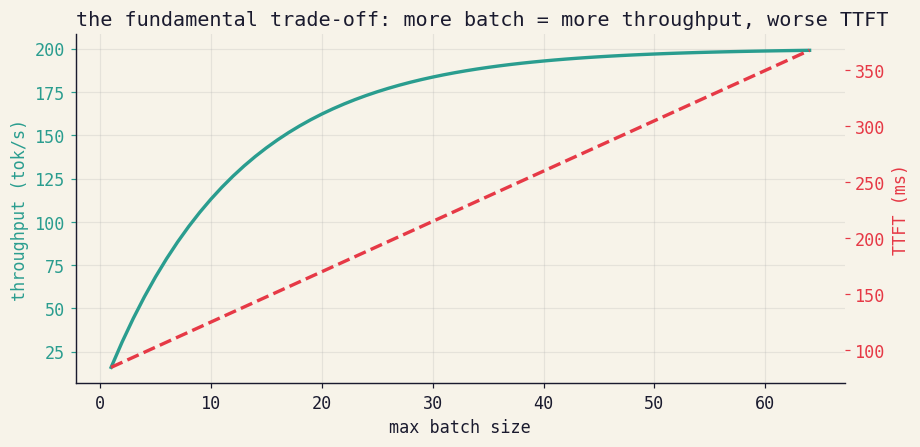

In [2]:
# Quick sanity sketch: the trade-off space.
# Imagine a serving system parameterized by max_batch_size.
# Throughput grows roughly with batch (until the GPU saturates).
# TTFT grows roughly linearly with queue depth (which scales with batch).

batch = np.arange(1, 65)
# Cartoon model: throughput = saturating function of batch
throughput = 200 * (1 - np.exp(-batch / 12))   # tokens/sec, asymptotes near 200
# Cartoon TTFT: low at small batch, climbs as we make people wait
ttft_ms = 80 + 4.5 * batch                      # ms

fig, ax1 = plt.subplots(figsize=(8.5, 4.2))
ax1.plot(batch, throughput, color=PALETTE["teal"], lw=2.2, label="throughput")
ax1.set_xlabel("max batch size")
ax1.set_ylabel("throughput (tok/s)", color=PALETTE["teal"])
ax1.tick_params(axis="y", colors=PALETTE["teal"])
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(batch, ttft_ms, color=PALETTE["rose"], lw=2.2, ls="--", label="TTFT")
ax2.set_ylabel("TTFT (ms)", color=PALETTE["rose"])
ax2.tick_params(axis="y", colors=PALETTE["rose"])
ax2.spines["top"].set_visible(False)

plt.title("the fundamental trade-off: more batch = more throughput, worse TTFT", loc="left")
plt.tight_layout()
plt.show()

That picture is a cartoon — your real system has more curves and more cliffs — but the *shape* is right. Throughput is a saturating function of batch size; latency is a roughly linear function of how long you let requests pile up. The interesting question, which most of this notebook is about, is: **can we move both curves at once?** Continuous batching, prefix caching, and clever scheduling all do exactly that.

## 2 · Prefill vs decode: two completely different bottlenecks

Inside a single forward pass, an LLM does two very different kinds of work:

**Prefill** is what happens when a request first arrives. You take the whole prompt — say 2000 tokens — and run it through every transformer layer in one big parallel batch. You're multiplying a $(2000 \times d)$ activation matrix against a $(d \times d)$ weight matrix. Lots of FLOPs. Lots of arithmetic intensity. The GPU's matrix cores are happy. **Prefill is compute-bound.**

**Decode** is what happens after that. To produce token $t+1$, you only need to do a forward pass on *one* token (because the previous tokens are cached as keys/values). But to do attention, that one token has to read every entry in the KV cache for every layer. You are not doing much arithmetic — you are *streaming gigabytes of cache through the memory system*. **Decode is memory-bandwidth-bound.**

This split is the single most important fact in inference engineering. Almost every optimization you'll meet attacks one side or the other:

- **Continuous batching** mainly helps decode (it lets you pile many decode steps into one matmul that *is* arithmetic-intense).
- **Prefix caching** mainly helps prefill (it skips redundant prompt computation).
- **Speculative decoding** (Module 25) attacks the decode bottleneck by making the bandwidth-bound step do useful work for several tokens at once.
- **Quantization** (Module 16) attacks decode by literally shrinking how many bytes you stream.
- **PagedAttention** (Module 14a) makes both feasible by killing memory waste so you can fit more requests in HBM.

If somebody tells you their inference engine is "fast" without specifying prefill or decode, they're either selling you something or they don't know what they're talking about.

In [3]:
# A back-of-envelope: prefill is FLOPs-bound, decode is bytes-bound.
# Numbers are illustrative — we just want to see the shape.

d_model    = 4096
n_layers   = 32
gpu_flops  = 312e12        # ~A100 fp16 dense
gpu_bw     = 2e12          # ~A100 HBM (bytes/sec)
bytes_per  = 2             # fp16

def prefill_time(prompt_len, batch=1):
    # ~2 * 2 * n_layers * d^2 * prompt_len * batch  flops (qkv + out + ffn collapsed into a constant)
    flops = 12 * n_layers * d_model * d_model * prompt_len * batch
    return flops / gpu_flops

def decode_time(kv_len, batch=1):
    # Streaming KV cache: 2 (K,V) * n_layers * d * kv_len * batch bytes per token generated
    kv_bytes = 2 * n_layers * d_model * kv_len * batch * bytes_per
    return kv_bytes / gpu_bw

prompt_lens = np.array([128, 512, 1024, 2048, 4096])
prefill_ms = np.array([prefill_time(p) * 1000 for p in prompt_lens])
decode_ms  = np.array([decode_time(p) * 1000 for p in prompt_lens])

print(f"{'prompt_len':>11}   {'prefill (ms)':>14}   {'1 decode step (ms)':>20}   ratio")
for p, pf, dc in zip(prompt_lens, prefill_ms, decode_ms):
    print(f"{p:>11d}   {pf:>14.2f}   {dc:>20.2f}   {pf/dc:>5.1f}x")

 prompt_len     prefill (ms)     1 decode step (ms)   ratio
        128             2.64                   0.03    78.8x
        512            10.57                   0.13    78.8x
       1024            21.14                   0.27    78.8x
       2048            42.29                   0.54    78.8x
       4096            84.58                   1.07    78.8x


See the ratio? Prefill of a 2k prompt is ~50x more work than a single decode step at the same context length. But you do prefill *once* per request and decode *hundreds* of times. So in a typical chat workload, **decode dominates wall-clock time** even though prefill dominates each individual forward pass. This is why decode optimizations are where the money is — and why batching, in particular, is so important: each decode step has so little arithmetic in it that the only way to keep the GPU fed is to do many of them at once.

## 3 · Continuous batching: the actual vLLM idea

Before vLLM, most servers used **static batching**. The flow looked like:

1. Wait for a batch of `B` requests to arrive (or a timeout).
2. Pad all prompts to the longest one.
3. Run prefill on the whole batch.
4. Decode in lockstep until *every* request in the batch hits its EOS or max length.
5. Return all `B` responses.
6. Go back to step 1.

This is catastrophic for two reasons:

- **Padding waste:** if requests want 50, 200, and 4000 tokens, the first two get dragged along for an extra 3950 decode steps, doing nothing useful.
- **Head-of-line blocking:** while step 4 is grinding through that 4000-token request, the next batch is sitting in the queue. New users wait. TTFT goes through the floor.

**Continuous batching** (sometimes called *iteration-level scheduling* or *in-flight batching*) reframes the problem at the level of one decoding step instead of one request. The flow becomes:

1. Maintain a "running batch" of in-flight requests.
2. Each step, run *one decode step* across the running batch.
3. Any request that just hit EOS? Drop it from the batch immediately.
4. Empty slots in the batch? Pull new requests from the queue and run their prefill. Possibly mixed into the same step (this is "chunked prefill" — modern engines do it).
5. Repeat forever.

The batch composition is a living thing now. Requests slide in and out at every step. You never wait for the slowest member. You never pad. You never starve the queue. **The shape is the win.** Let's see it.

In [4]:
# Generate a workload of 20 requests with realistic-ish length distributions.
# Prompt: lognormal around 200 tokens. Output: lognormal around 150 tokens.
N_REQUESTS = 20

def make_workload(n, seed):
    r = np.random.default_rng(seed)
    arrivals = np.sort(r.uniform(0, 30, size=n))            # arrive over 30 "time units"
    prompt_lens = np.clip(r.lognormal(mean=5.2, sigma=0.6, size=n), 50, 2000).astype(int)
    output_lens = np.clip(r.lognormal(mean=4.8, sigma=0.7, size=n), 20, 800).astype(int)
    return arrivals, prompt_lens, output_lens

arrivals, prompt_lens, output_lens = make_workload(N_REQUESTS, seed=7)
print("first 5 requests:")
print(f"{'#':>3} {'arrival':>9} {'prompt':>8} {'output':>8}")
for i in range(5):
    print(f"{i:>3} {arrivals[i]:>9.2f} {prompt_lens[i]:>8d} {output_lens[i]:>8d}")
print(f"\ntotal prompt tokens : {prompt_lens.sum()}")
print(f"total output tokens : {output_lens.sum()}")
print(f"longest output      : {output_lens.max()}")
print(f"shortest output     : {output_lens.min()}")

first 5 requests:
  #   arrival   prompt   output
  0      0.16       60      131
  1      6.76      157      127
  2      7.65       84       51
  3      8.35      213      128
  4      9.00      199      314

total prompt tokens : 3079
total output tokens : 3298
longest output      : 492
shortest output     : 41


Now we build the simulator. We'll model time in discrete "steps." Each step corresponds to one decode iteration in real life. We track which slots of a fixed-size batch are occupied, when each request started/finished, and how many tokens were produced this step. Two policies: `static` (wait for the whole batch to finish) and `continuous` (admit new requests as old ones complete).

In [5]:
@dataclass
class Request:
    rid: int
    arrival: float
    prompt_len: int
    output_len: int
    start_step: Optional[int] = None     # step at which prefill happened
    first_token_step: Optional[int] = None
    finish_step: Optional[int] = None
    tokens_done: int = 0

def simulate(arrivals, prompt_lens, output_lens, max_batch=8, mode="continuous",
             prefill_cost_per_tok=0.02, decode_cost=1.0, max_steps=4000):
    """Tiny serving simulator. One 'step' ~ one decode iteration's worth of GPU time.

    mode='static'     : wait until the running batch fully drains before admitting any new req.
    mode='continuous' : as soon as ANY slot frees, admit the next queued request.
    """
    n = len(arrivals)
    requests = [Request(rid=i, arrival=arrivals[i], prompt_len=int(prompt_lens[i]),
                        output_len=int(output_lens[i])) for i in range(n)]
    queue = deque(requests)
    running: List[Request] = []
    timeline = []     # (step, [rid for slot in batch], n_useful_tokens_this_step)
    step = 0
    # We measure simulated wall time alongside steps; prefill costs more "wall" than decode.
    wall = 0.0

    while queue or running:
        # 1. Admission policy
        if mode == "static":
            if not running:
                # Drain queue up to max_batch — the classic static batch.
                while queue and len(running) < max_batch and queue[0].arrival <= wall + 1e-6:
                    req = queue.popleft()
                    req.start_step = step
                    running.append(req)
        elif mode == "continuous":
            while queue and len(running) < max_batch and queue[0].arrival <= wall + 1e-6:
                req = queue.popleft()
                req.start_step = step
                running.append(req)
        else:
            raise ValueError(mode)

        if not running:
            # Idle: advance wall to next arrival.
            if queue:
                wall = max(wall, queue[0].arrival)
                continue
            else:
                break

        # 2. Prefill cost for any newly admitted requests this step.
        # Real engines often do chunked prefill; we lump it into one step.
        new_prefill_tokens = sum(r.prompt_len for r in running if r.first_token_step is None)
        prefill_time_this_step = new_prefill_tokens * prefill_cost_per_tok

        # 3. One decode step for every running request.
        useful_tokens = 0
        finished = []
        for r in running:
            if r.first_token_step is None:
                r.first_token_step = step
            r.tokens_done += 1
            useful_tokens += 1
            if r.tokens_done >= r.output_len:
                r.finish_step = step
                finished.append(r)

        timeline.append((step, [r.rid for r in running], useful_tokens, len(running)))

        # advance time
        wall += decode_cost + prefill_time_this_step
        step += 1
        if step > max_steps:
            break

        # 4. Eviction
        if mode == "continuous":
            for r in finished:
                running.remove(r)
        elif mode == "static":
            # Only drain the whole batch when ALL members finish.
            if all(r.finish_step is not None for r in running):
                running.clear()

    return requests, timeline, wall

# Run both policies on the same workload.
reqs_static, tl_static, wall_static = simulate(arrivals, prompt_lens, output_lens,
                                                max_batch=8, mode="static")
reqs_cont,   tl_cont,   wall_cont   = simulate(arrivals, prompt_lens, output_lens,
                                                max_batch=8, mode="continuous")

def stats(reqs, wall):
    finished = [r for r in reqs if r.finish_step is not None]
    n_tok = sum(r.output_len for r in finished)
    ttfts = [r.first_token_step - r.arrival for r in finished if r.first_token_step is not None]
    return dict(n=len(finished), tokens=n_tok, wall=wall,
                throughput=n_tok / max(wall, 1e-9),
                mean_ttft=np.mean(ttfts), p99_ttft=np.percentile(ttfts, 99))

s_stat = stats(reqs_static, wall_static)
s_cont = stats(reqs_cont,   wall_cont)
print(f"{'metric':>18}   {'static':>12}   {'continuous':>12}")
print(f"{'wall (sim)':>18}   {s_stat['wall']:>12.1f}   {s_cont['wall']:>12.1f}")
print(f"{'throughput tok/s':>18}   {s_stat['throughput']:>12.2f}   {s_cont['throughput']:>12.2f}")
print(f"{'mean TTFT':>18}   {s_stat['mean_ttft']:>12.2f}   {s_cont['mean_ttft']:>12.2f}")
print(f"{'P99 TTFT':>18}   {s_stat['p99_ttft']:>12.2f}   {s_cont['p99_ttft']:>12.2f}")

            metric         static     continuous
        wall (sim)         1330.7          654.7
  throughput tok/s           2.48           5.04
         mean TTFT         353.66          85.46
          P99 TTFT         909.56         275.72


Static finishes the same workload more slowly *and* with worse TTFT, because every request has to sit through the slowest peer in its batch and the queue piles up behind it. Continuous wins on every axis because no request ever waits for an unrelated long one.

The numbers are nice but the picture is better. Let's draw the GPU's batch composition over time for both policies. Each row is a slot in the batch. Each colored cell is a request occupying that slot at that step. The grey cells are the wasted slots — a slot the GPU paid to keep alive but had no useful request in it.

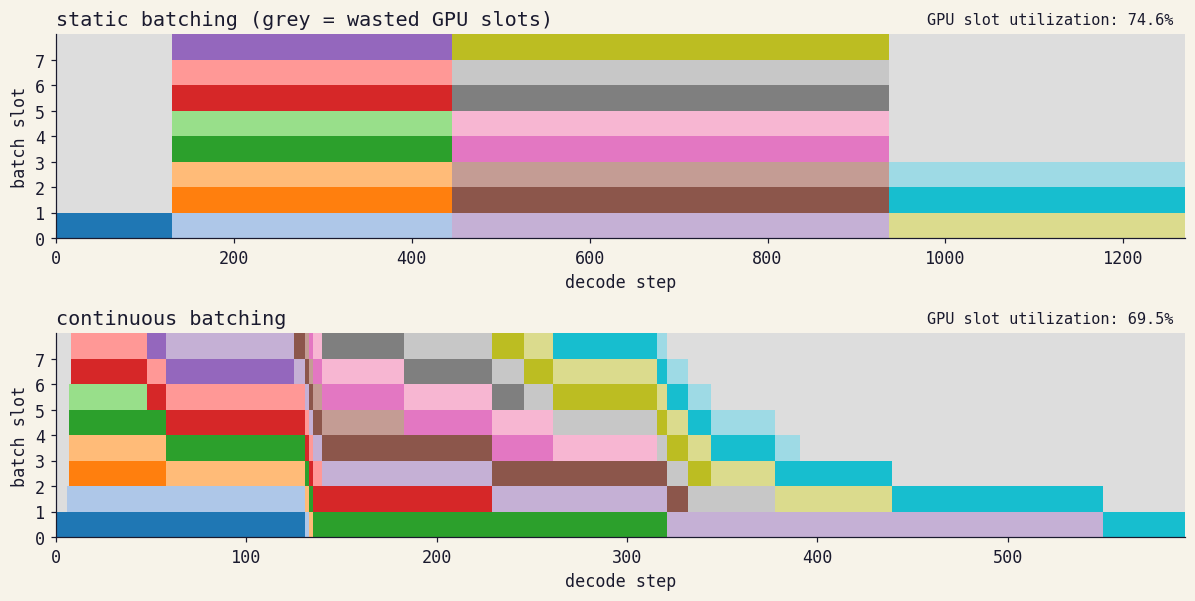

In [6]:
def render_timeline(timeline, max_batch, requests, ax, title):
    n_req = len(requests)
    cmap = plt.get_cmap("tab20", n_req)

    n_steps = len(timeline)
    grid = np.full((max_batch, n_steps), -1, dtype=int)
    for t, (step, rids, _useful, _n) in enumerate(timeline):
        for slot_idx, rid in enumerate(rids):
            if slot_idx < max_batch:
                grid[slot_idx, t] = rid

    # Draw
    for slot in range(max_batch):
        for t in range(n_steps):
            rid = grid[slot, t]
            if rid == -1:
                color = "#dddddd"   # waste
            else:
                color = cmap(rid % 20)
            ax.add_patch(patches.Rectangle((t, slot), 1, 1, facecolor=color, edgecolor="none"))

    ax.set_xlim(0, n_steps)
    ax.set_ylim(0, max_batch)
    ax.set_xlabel("decode step")
    ax.set_ylabel("batch slot")
    ax.set_title(title, loc="left")
    ax.set_yticks(range(max_batch))
    # Compute waste %
    total_cells = max_batch * n_steps
    wasted = (grid == -1).sum()
    util = 100 * (1 - wasted / total_cells)
    ax.text(0.99, 1.05, f"GPU slot utilization: {util:.1f}%",
            transform=ax.transAxes, ha="right", color=PALETTE["ink"], fontsize=10)

fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=False)
render_timeline(tl_static, 8, reqs_static, axes[0], "static batching (grey = wasted GPU slots)")
render_timeline(tl_cont,   8, reqs_cont,   axes[1], "continuous batching")
plt.tight_layout()
plt.show()

Look at the difference. Static is a parking lot of grey — every batch is dragged forward by its longest request. Continuous keeps the slots packed because finishing a request immediately releases its slot for the next one in the queue.

That picture is what people mean when they say vLLM "tripled their throughput." It's not a faster matmul. It's the same matmul running on a denser batch.

### Throughput vs latency under varying load

The previous experiment used one workload. Let's sweep the request rate and trace out the *operating curves* of both policies. This is the chart you'll see in every serving paper. It's also the chart you should make your own engineers draw before they're allowed to claim a speedup.

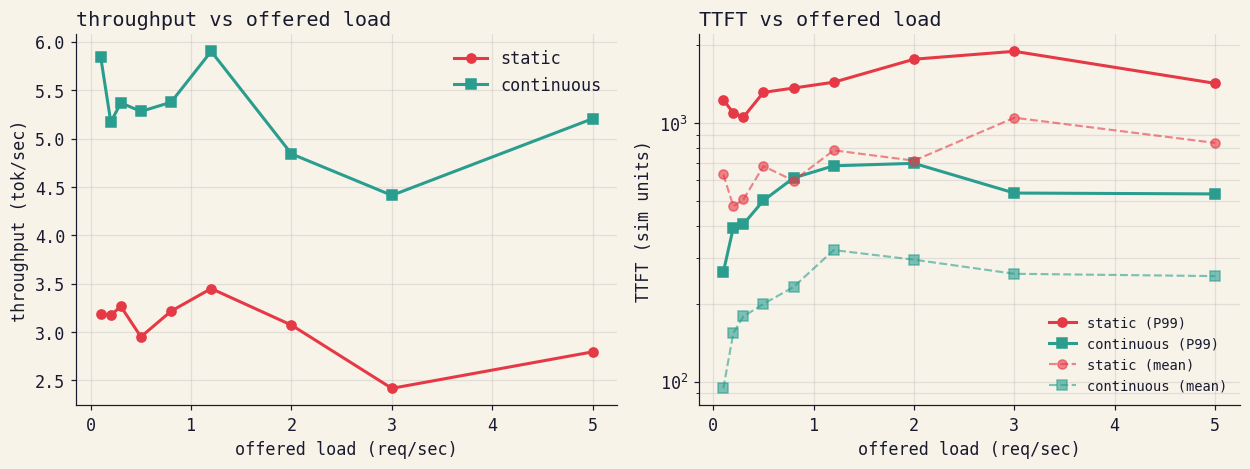

In [7]:
def sweep_load(rates, mode, n_per=40, max_batch=8, seed_base=100):
    out = []
    for rate in rates:
        # Generate n_per requests with mean inter-arrival 1/rate
        r = np.random.default_rng(seed_base + int(rate * 100))
        inter = r.exponential(scale=1.0/rate, size=n_per)
        arrivals = np.cumsum(inter)
        prompts = np.clip(r.lognormal(5.2, 0.6, size=n_per), 50, 2000).astype(int)
        outputs = np.clip(r.lognormal(4.8, 0.7, size=n_per), 20, 800).astype(int)
        reqs, _tl, wall = simulate(arrivals, prompts, outputs, max_batch=max_batch, mode=mode)
        s = stats(reqs, wall)
        out.append((rate, s["throughput"], s["mean_ttft"], s["p99_ttft"]))
    return np.array(out)

rates = np.array([0.1, 0.2, 0.3, 0.5, 0.8, 1.2, 2.0, 3.0, 5.0])
sw_static = sweep_load(rates, "static")
sw_cont   = sweep_load(rates, "continuous")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

axes[0].plot(sw_static[:, 0], sw_static[:, 1], "o-", color=PALETTE["rose"],   lw=2, label="static")
axes[0].plot(sw_cont[:, 0],   sw_cont[:, 1],   "s-", color=PALETTE["teal"],   lw=2, label="continuous")
axes[0].set_xlabel("offered load (req/sec)")
axes[0].set_ylabel("throughput (tok/sec)")
axes[0].set_title("throughput vs offered load", loc="left")
axes[0].grid(alpha=0.3)
axes[0].legend(frameon=False)

axes[1].plot(sw_static[:, 0], sw_static[:, 3], "o-", color=PALETTE["rose"],  lw=2, label="static (P99)")
axes[1].plot(sw_cont[:, 0],   sw_cont[:, 3],   "s-", color=PALETTE["teal"],  lw=2, label="continuous (P99)")
axes[1].plot(sw_static[:, 0], sw_static[:, 2], "o--", color=PALETTE["rose"], lw=1.4, alpha=0.6, label="static (mean)")
axes[1].plot(sw_cont[:, 0],   sw_cont[:, 2],   "s--", color=PALETTE["teal"], lw=1.4, alpha=0.6, label="continuous (mean)")
axes[1].set_xlabel("offered load (req/sec)")
axes[1].set_ylabel("TTFT (sim units)")
axes[1].set_title("TTFT vs offered load", loc="left")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

Two things to notice.

1. **Continuous batching has a higher saturation throughput.** The static curve flattens earlier because it's wasting GPU on padding. Continuous keeps climbing.
2. **Static's P99 TTFT explodes** as load goes up. This is the "queue forms a queue" effect — a few unlucky users wait many full batches deep. Continuous keeps P99 manageable for much longer because it never makes anyone wait for an unrelated long peer.

The mean is a liar. Always look at P99. The 1% you ignore is the 1% of users who write angry tweets about your product.

## 4 · Prefix caching (copy-on-write KV)

Now a different optimization. Look at any chat-product workload and you will find one ugly truth: **most requests share a system prompt.** "You are a helpful assistant. Today's date is... Here are some rules... Format your output as..." Two thousand tokens of identical prefix on every single request.

Naive serving recomputes that prefix prefill every single time. PagedAttention (Module 14a) gave us the building block to fix this: KV cache is stored in fixed-size blocks rather than per-request contiguous buffers. Once you have blocks, you can do a beautiful trick: **share blocks between requests that share a prefix.** When one request needs to write, it copies-on-write only the block it modifies. Every other block stays shared.

The math is:

$$
\text{prefill\_savings} = N_{\text{requests}} \cdot L_{\text{shared\_prefix}} - L_{\text{shared\_prefix}}
$$

You pay the prefix cost once instead of $N$ times. For workloads with a 2000-token system prompt and 50 concurrent requests, that's a *50x reduction in prefill compute* on the shared portion. RAG and agent workloads also benefit hugely — the retrieved documents and the tool definitions are usually identical across calls.

In [8]:
# Simulate prefix caching savings on a workload where every request shares a 2000-token system prompt.

def workload_with_shared_prefix(n, shared_len, seed):
    r = np.random.default_rng(seed)
    arrivals = np.sort(r.uniform(0, 30, size=n))
    user_lens = np.clip(r.lognormal(4.2, 0.5, size=n), 20, 400).astype(int)
    output_lens = np.clip(r.lognormal(4.8, 0.6, size=n), 20, 600).astype(int)
    prompt_lens = user_lens + shared_len
    return arrivals, prompt_lens, output_lens, user_lens

SHARED = 2000
N = 20
arr2, pl2, ol2, ul2 = workload_with_shared_prefix(N, shared_len=SHARED, seed=11)
print(f"Each request has a {SHARED}-token shared system prompt + {ul2.mean():.0f}-token user msg on average.")
print(f"Total prompt tokens (no cache):   {pl2.sum():>8d}")
print(f"Total prompt tokens (with cache): {SHARED + ul2.sum():>8d}")
print(f"Reduction: {(1 - (SHARED + ul2.sum())/pl2.sum())*100:.1f}%")

Each request has a 2000-token shared system prompt + 60-token user msg on average.
Total prompt tokens (no cache):      41200
Total prompt tokens (with cache):     3200
Reduction: 92.2%


In [9]:
# Re-run our simulator on both: with and without prefix cache.
# 'with cache' means we only pay the shared prefill once in total.

def simulate_with_cache(arrivals, prompt_lens, output_lens, shared_len, max_batch=8,
                        prefill_cost_per_tok=0.02, decode_cost=1.0):
    """Same continuous-batching simulator, but the first time we see the shared prefix
    we pay full price; every subsequent request only pays for its (prompt - shared) tail."""
    effective = prompt_lens.copy()
    effective[1:] = effective[1:] - shared_len   # only the first request pays shared prefix
    return simulate(arrivals, effective, output_lens, max_batch=max_batch,
                    mode="continuous",
                    prefill_cost_per_tok=prefill_cost_per_tok,
                    decode_cost=decode_cost)

reqs_nocache, _, wall_nocache = simulate(arr2, pl2, ol2, max_batch=8, mode="continuous")
reqs_cache,   _, wall_cache   = simulate_with_cache(arr2, pl2, ol2, SHARED, max_batch=8)

s_nc = stats(reqs_nocache, wall_nocache)
s_c  = stats(reqs_cache,   wall_cache)
print(f"{'metric':>18}   {'no cache':>12}   {'prefix cache':>14}")
print(f"{'wall (sim)':>18}   {s_nc['wall']:>12.1f}   {s_c['wall']:>14.1f}")
print(f"{'throughput tok/s':>18}   {s_nc['throughput']:>12.2f}   {s_c['throughput']:>14.2f}")
print(f"{'mean TTFT':>18}   {s_nc['mean_ttft']:>12.2f}   {s_c['mean_ttft']:>14.2f}")
print(f"{'P99 TTFT':>18}   {s_nc['p99_ttft']:>12.2f}   {s_c['p99_ttft']:>14.2f}")
print(f"\nspeedup: {s_nc['wall']/s_c['wall']:.2f}x wall, {s_c['throughput']/s_nc['throughput']:.2f}x throughput")

            metric       no cache     prefix cache
        wall (sim)         1250.9            490.9
  throughput tok/s           2.21             5.64
         mean TTFT          73.10            73.10
          P99 TTFT         240.68           240.68

speedup: 2.55x wall, 2.55x throughput


Big number. And it gets bigger the longer the shared prefix is and the more concurrent users you have. Some real production workloads see 10x-20x speedups from prefix caching alone because the shared prompt is enormous (think long instruction sets, retrieved RAG context, few-shot examples).

The catch: prefix caching only helps when prefixes *actually* match exactly, byte for byte. One stray timestamp, one user-specific name in the system prompt, and your cache hit rate drops to zero. The cardinal rule of building a chat product on a serving engine you care about: **put the per-user, per-turn variable junk at the END of the prompt, not the beginning.**

Modern engines go further than block-level matching. SGLang's *RadixAttention* maintains a radix tree over all live prefixes, so partial matches (e.g. "system prompt + first 3 turns of conversation") are reused too. We won't simulate the radix tree — the point is just that the more cleverly you organize the cache, the more you can reuse.

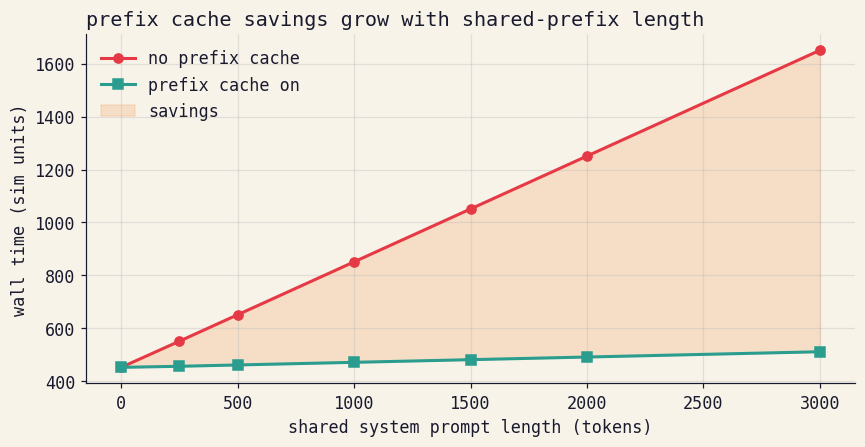

In [10]:
# Sweep: what if we vary the shared prefix length?
shared_lens = np.array([0, 250, 500, 1000, 1500, 2000, 3000])
nc_walls, c_walls = [], []
for s_len in shared_lens:
    a, p, o, _ = workload_with_shared_prefix(N, shared_len=int(s_len), seed=11)
    _, _, w_nc = simulate(a, p, o, max_batch=8, mode="continuous")
    _, _, w_c  = simulate_with_cache(a, p, o, int(s_len), max_batch=8)
    nc_walls.append(w_nc)
    c_walls.append(w_c)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(shared_lens, nc_walls, "o-", color=PALETTE["rose"], lw=2, label="no prefix cache")
ax.plot(shared_lens, c_walls,  "s-", color=PALETTE["teal"], lw=2, label="prefix cache on")
ax.fill_between(shared_lens, c_walls, nc_walls, color=PALETTE["amber"], alpha=0.25, label="savings")
ax.set_xlabel("shared system prompt length (tokens)")
ax.set_ylabel("wall time (sim units)")
ax.set_title("prefix cache savings grow with shared-prefix length", loc="left")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

At zero shared prefix, the two lines meet — there's nothing to cache. As the prefix grows, the no-cache line climbs linearly because every request pays for it; the cache line stays flat because only one request ever pays. The amber wedge is free money. Take the free money.

## 5 · Scheduling policies: who goes first?

So far we've assumed FCFS — first-come, first-served. The queue is a simple FIFO. In practice, every serious engine exposes a scheduler and you can usually plug in a policy. Three common ones:

| Policy | What it does | Helps | Hurts |
|---|---|---|---|
| **FCFS** | First in, first out | Predictable. Fair in a "wall-clock" sense. | A 4000-token request can block 50 short ones. |
| **SJF** (shortest-job-first) | Pull short requests first | Mean TTFT, mean latency | Long requests can starve. Adversarial users can game it. |
| **Priority** | Tag requests with a class; serve higher priority first | Important traffic (e.g. paying customers) | Lower-priority traffic gets ugly TTFT. |
| **Fair queuing** | Round-robin across users/tenants | Multi-tenant fairness | Slightly lower aggregate throughput. |

Notice the language: every policy *helps something* and *hurts something*. There is no free policy. The right choice depends on what your product is and what your SLA actually says. Let's compare FCFS and SJF on the same workload.

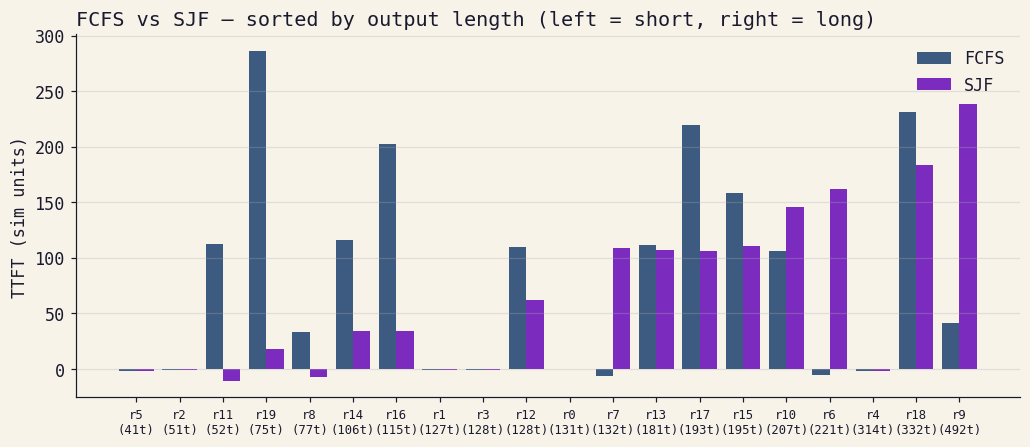

FCFS  mean TTFT: 85.46   P99: 275.72
SJF   mean TTFT: 64.21   P99: 227.93


In [11]:
def simulate_sjf(arrivals, prompt_lens, output_lens, max_batch=8,
                 prefill_cost_per_tok=0.02, decode_cost=1.0):
    """Continuous batching, but the queue is sorted by output_len (shortest first)
    among already-arrived requests. Real-world SJF can only use estimates; we cheat
    by using the true length because we want the upper-bound shape."""
    n = len(arrivals)
    requests = [Request(rid=i, arrival=arrivals[i], prompt_len=int(prompt_lens[i]),
                        output_len=int(output_lens[i])) for i in range(n)]
    pending = list(requests)            # not yet arrived
    queue = []                          # arrived but not running
    running: List[Request] = []
    timeline = []
    step = 0
    wall = 0.0

    while pending or queue or running:
        # Move arrived requests from pending to queue
        new_arrivals = [r for r in pending if r.arrival <= wall + 1e-6]
        for r in new_arrivals:
            queue.append(r)
            pending.remove(r)
        # Sort queue by predicted output length (shortest first)
        queue.sort(key=lambda r: r.output_len)

        # Admit
        while queue and len(running) < max_batch:
            r = queue.pop(0)
            r.start_step = step
            running.append(r)

        if not running:
            if pending:
                wall = max(wall, min(r.arrival for r in pending))
                continue
            break

        new_prefill = sum(r.prompt_len for r in running if r.first_token_step is None)
        prefill_t = new_prefill * prefill_cost_per_tok

        finished = []
        for r in running:
            if r.first_token_step is None:
                r.first_token_step = step
            r.tokens_done += 1
            if r.tokens_done >= r.output_len:
                r.finish_step = step
                finished.append(r)

        timeline.append((step, [r.rid for r in running], len(running), len(running)))
        wall += decode_cost + prefill_t
        step += 1
        for r in finished:
            running.remove(r)

    return requests, timeline, wall

reqs_fcfs, _, wall_fcfs = simulate(arrivals, prompt_lens, output_lens, max_batch=8, mode="continuous")
reqs_sjf,  _, wall_sjf  = simulate_sjf(arrivals, prompt_lens, output_lens, max_batch=8)

# Per-request TTFT (using arrival as time 0)
ttft_fcfs = np.array([r.first_token_step - r.arrival for r in reqs_fcfs])
ttft_sjf  = np.array([r.first_token_step - r.arrival for r in reqs_sjf])

# Sort by request output length so we can see who pays
order = np.argsort(output_lens)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = np.arange(len(order))
ax.bar(x - 0.2, ttft_fcfs[order], width=0.4, color=PALETTE["indigo"], label="FCFS")
ax.bar(x + 0.2, ttft_sjf[order],  width=0.4, color=PALETTE["plum"],   label="SJF")
ax.set_xticks(x)
ax.set_xticklabels([f"r{i}\n({output_lens[i]}t)" for i in order], fontsize=8)
ax.set_ylabel("TTFT (sim units)")
ax.set_title("FCFS vs SJF — sorted by output length (left = short, right = long)", loc="left")
ax.legend(frameon=False)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"FCFS  mean TTFT: {ttft_fcfs.mean():.2f}   P99: {np.percentile(ttft_fcfs, 99):.2f}")
print(f"SJF   mean TTFT: {ttft_sjf.mean():.2f}   P99: {np.percentile(ttft_sjf, 99):.2f}")

SJF gives short requests faster TTFT and worse TTFT to the long ones. The mean improves, but if you are unlucky enough to be the user with the long output you wait *more*. This is the policy lesson in miniature. **Every scheduler is a choice about whose latency you're willing to sacrifice.**

Two things to remember in production:

1. You don't *actually* know the output length when the request arrives. SJF requires an estimator (sometimes called a "length predictor"). Modern serving systems train a tiny classifier on the prompt to predict the output bucket. It's noisy but useful.
2. SJF can starve. Real implementations add an "aging" term so requests that have been waiting for a long time get a priority bump. Otherwise that 4000-token request might *literally never* run during a busy hour.

## 6 · Speculative decoding, briefly

Module 25 covered this in depth so we won't redo it. The relevant fact for *serving*: vLLM and TensorRT-LLM both ship pluggable speculator support. You point the engine at a draft model (or a Medusa head, or an EAGLE feature predictor), set a `num_speculative_tokens`, and the engine handles the verify-and-rollback dance for you.

The interesting interaction is with batching: **speculative decoding's per-step gain shrinks when the batch is large**, because the GPU is no longer memory-bandwidth-bound — it's compute-bound, and the draft model's extra forward passes start to cost real time. This is one of the cleanest examples of "two optimizations that don't compose linearly." A fact your benchmark spreadsheet should reflect.

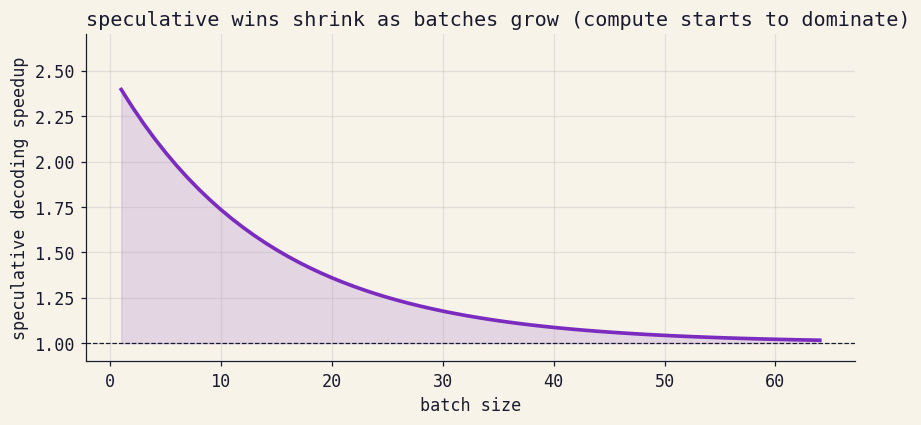

In [12]:
# Cartoon: how speculative decoding's effective speedup changes with batch size.
batch = np.arange(1, 65)
# At batch=1 we are bandwidth-bound: speculative gives ~2.5x.
# As batch grows, decode becomes compute-bound and speculative drafts cost real flops.
spec_speedup = 1 + 1.5 * np.exp(-batch / 14)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(batch, spec_speedup, color=PALETTE["plum"], lw=2.4)
ax.axhline(1.0, color=PALETTE["ink"], lw=0.8, ls="--")
ax.fill_between(batch, 1.0, spec_speedup, color=PALETTE["plum"], alpha=0.15)
ax.set_xlabel("batch size")
ax.set_ylabel("speculative decoding speedup")
ax.set_title("speculative wins shrink as batches grow (compute starts to dominate)", loc="left")
ax.set_ylim(0.9, 2.7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Translation: speculative decoding is a *latency* optimization, not a *throughput* optimization. It helps the small-batch, low-load regime — typically your interactive chat traffic. It does not help the saturated, high-batch, batch-job regime where you're already keeping the GPU's matrix cores fed.

## 7 · Break it on purpose

Two break-it experiments. The point of every break-it cell in this curriculum is the same: when you remove an optimization and the world ends, you understand what the optimization was buying you.

### Break #1: kill continuous batching

We've already done the comparison above on the small workload, but let's pile on the load and watch static fall over while continuous holds. The shape we expect: at low load, both look fine. At higher load, static's queue blows up because of head-of-line blocking, while continuous degrades gracefully.

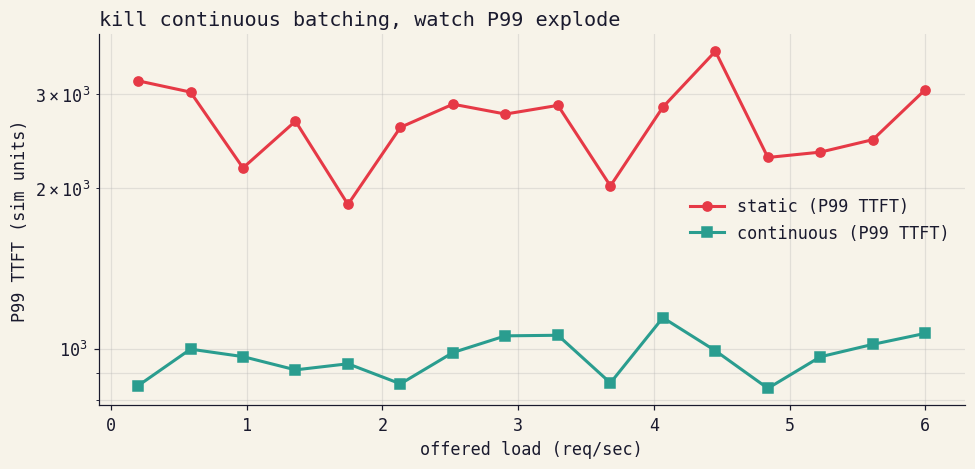

In [13]:
rates2 = np.linspace(0.2, 6.0, 16)
sw_static2 = sweep_load(rates2, "static",     n_per=60, max_batch=8)
sw_cont2   = sweep_load(rates2, "continuous", n_per=60, max_batch=8)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(sw_static2[:, 0], sw_static2[:, 3], "o-", color=PALETTE["rose"], lw=2, label="static (P99 TTFT)")
ax.plot(sw_cont2[:, 0],   sw_cont2[:, 3],   "s-", color=PALETTE["teal"], lw=2, label="continuous (P99 TTFT)")
ax.set_xlabel("offered load (req/sec)")
ax.set_ylabel("P99 TTFT (sim units)")
ax.set_yscale("log")
ax.set_title("kill continuous batching, watch P99 explode", loc="left")
ax.grid(alpha=0.3, which="both")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The static line goes vertical. That's the cliff. In a real system that cliff is the moment your alerting wakes you up. Continuous batching is mostly what keeps you on the safe side of it.

### Break #2: kill prefix caching on a system-prompt-heavy workload

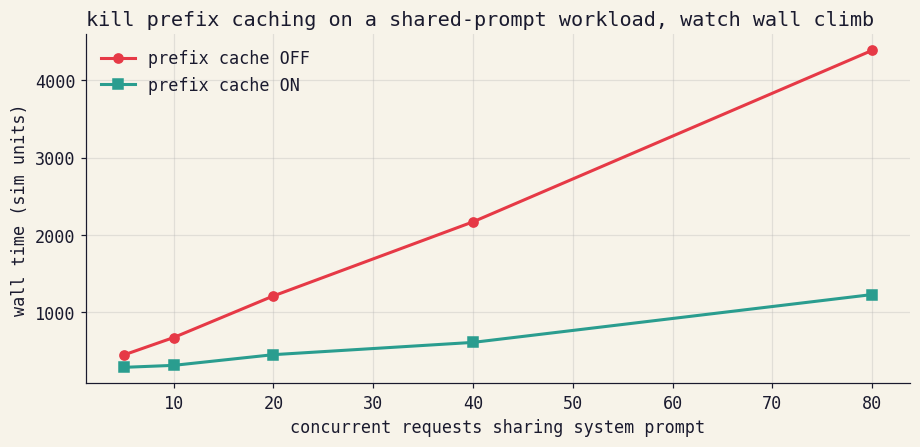

  N=  5: prefix cache is 1.56x faster
  N= 10: prefix cache is 2.15x faster
  N= 20: prefix cache is 2.68x faster
  N= 40: prefix cache is 3.56x faster
  N= 80: prefix cache is 3.57x faster


In [14]:
# Same shared-prefix workload, but compare the wall time as we increase concurrency.
counts = np.array([5, 10, 20, 40, 80])
nc_w, c_w = [], []
for n in counts:
    a, p, o, _ = workload_with_shared_prefix(int(n), shared_len=2000, seed=42)
    _, _, w_nc = simulate(a, p, o, max_batch=16, mode="continuous")
    _, _, w_c  = simulate_with_cache(a, p, o, 2000, max_batch=16)
    nc_w.append(w_nc)
    c_w.append(w_c)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(counts, nc_w, "o-", color=PALETTE["rose"], lw=2, label="prefix cache OFF")
ax.plot(counts, c_w,  "s-", color=PALETTE["teal"], lw=2, label="prefix cache ON")
ax.set_xlabel("concurrent requests sharing system prompt")
ax.set_ylabel("wall time (sim units)")
ax.set_title("kill prefix caching on a shared-prompt workload, watch wall climb", loc="left")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ratios = np.array(nc_w) / np.array(c_w)
for n, r in zip(counts, ratios):
    print(f"  N={n:>3d}: prefix cache is {r:.2f}x faster")

The win grows with $N$. If your workload is an agent that spawns 80 parallel tool calls, all of which share a system prompt and tool definitions, the difference between cache-on and cache-off is the difference between a system that is usable and a system that is not.

These two break-it experiments are also the two things to *test* on day one when you stand up a serving engine. Send a load-shaped traffic profile through it. Send a shared-prompt traffic profile through it. If the engine is configured wrong (or doesn't do these things at all), the numbers will be obvious.

## 8 · The 2026 serving landscape

You will not be writing your own serving engine. You will be picking one. Here's the honest state of the world as of April 2026.

**vLLM** — the open-source default. PagedAttention's home, mature continuous batching, prefix caching on by default, plug-in speculator support, broad hardware coverage (NVIDIA, AMD, Intel, TPU, Trainium, Spyre, Ascend). When in doubt, ship vLLM. It's where the community is, where the bug fixes land first, and the only engine that won't lock you to a single GPU vendor.

**SGLang** — co-designed frontend + runtime. Its killer feature is *RadixAttention* — a radix tree over all live KV prefixes that lets it reuse partial matches automatically. On workloads with shared context (RAG, multi-turn, long system prompts) it consistently beats vLLM by ~25–30% on throughput. The frontend DSL also lets you express structured output and branching prompts in a way that compiles down to fewer GPU calls. If your workload is "many requests share lots of structure," it's the right pick.

**TGI** (Text Generation Inference) — HuggingFace's server. Now in maintenance mode. HuggingFace themselves recommend migrating to vLLM or SGLang. Don't start a new project on TGI in 2026.

**TensorRT-LLM** — NVIDIA's optimized engine. Wins on raw throughput on Hopper/Blackwell — typically 10–30% over vLLM at high concurrency, more if you tune it. The cost is brutal lock-in (NVIDIA only) and a 1–2 week bring-up time per model. Reasonable choice if you're a hyperscaler running a fixed model on a fixed GPU and the squeeze matters. Bad choice if you change models often.

**llama.cpp** — CPU/Metal/GGUF inference. Doesn't compete with vLLM on a GPU server, but it's the best thing in the world for "I want to run a 7B model on my laptop without a GPU" and for embedded / on-device deployments. The GGUF format is the de facto standard for quantized model files now.

**Ollama** — wraps llama.cpp with a friendly CLI and a model library. Fine for local hacking. Not a serving engine for production.

A useful 2026 decision tree:

```
 Does the workload share lots of context?
    yes -> SGLang
    no  -> are you NVIDIA-only and willing to spend a week tuning?
              yes -> TensorRT-LLM
              no  -> vLLM
 On-device / no GPU?
    yes -> llama.cpp (or Ollama for ergonomics)
```

The most important thing about this list is that you can, in principle, swap any of them out. They all expose an OpenAI-compatible HTTP API. Which is exactly the abstraction Module 27 picks up.

## 9 · Things I wish I'd known earlier

A grab bag of opinions from people who have been on call.

- **"Throughput" alone is a meaningless number.** Always pair it with a latency target. "200 tok/s at P99 < 800ms" is a number. "200 tok/s" is marketing.
- **Prefix-cache misses are silent.** A small change to your system prompt (e.g. adding a timestamp) can drop your hit rate from 95% to 0% with no error message. Monitor cache hit rate as a first-class metric.
- **Decode is bandwidth-bound, so quantization usually pays off twice.** Once on memory footprint, once on decode wall-clock. INT8/INT4 isn't just smaller — it's *faster*. (See Module 16.)
- **Long requests are landmines.** Whatever your scheduler is, a single 32k-token request can wreck batch composition for everyone behind it. Most production systems either cap context or maintain a separate "long-request lane" with its own GPU.
- **Watch GPU memory, not GPU util.** GPU util can be 99% while you're streaming KV cache and doing no real work. Memory pressure is what causes OOMs and OOMs are what cause 5xx storms.
- **Always test with a Poisson arrival process, not a uniform one.** Real traffic is bursty. Uniform load tests will always look prettier than reality.
- **TTFT is dominated by prefill on long prompts and by queue time on short ones.** Know which regime you're in before you "optimize."
- **The biggest perf wins are usually configuration, not code.** Default vLLM is already pretty good; the difference between a happy and an unhappy deployment is usually `max_num_batched_tokens`, `gpu_memory_utilization`, and whether you remembered to turn prefix cache on.

## 10 · Checkpoint

Five questions. Stop and try them before peeking.

**Q1.** A user complains that ChatGPT-style streaming feels janky on your serving deployment — tokens come in long pauses rather than smoothly. Throughput is fine. Which of the four metrics (throughput, TTFT, TPOT, P99) is the actual problem and what does that tell you about where to look?

<details><summary>answer</summary>

**TPOT** — time per output token. Throughput is total tok/s across all users; you can have great throughput and terrible TPOT if a few users are getting most of the tokens or if tokens are being delivered in bursts. Janky streaming with healthy throughput almost always means decode steps are getting starved by other work — usually a giant prefill (or a chunked prefill that isn't chunked finely enough) is blocking the decode loop, or your scheduler is round-tripping requests through CPU between steps.

Look at: chunked prefill settings, scheduler step time, network buffering on the streaming path, and whether you're flushing tokens to the client per-token or batching them up.

</details>

**Q2.** Your colleague proposes "let's just always run with `max_batch_size = 256` for max throughput." You disagree. What's the strongest single counterexample you can give them?

<details><summary>answer</summary>

A chat product where TTFT matters. Bumping max batch size pushes more requests into the running batch, which is great for tokens-per-second but means new requests wait longer for a slot to free (and pay a longer prefill stall when admitted). On low-rate, latency-sensitive workloads you want a *small* max batch — sometimes single digits — so that an arriving request gets prefilled and started immediately. The right number is workload-dependent, full stop. A batch-summarization job and an interactive chat product should not have the same setting.

Bonus answer: KV cache memory. A bigger max batch means more concurrent KV. Past some point you OOM, and OOMs cascade into 5xxs. The "free" throughput from a giant batch is paid for in memory pressure.

</details>

**Q3.** You add a prefix cache to your engine and your offline benchmark shows a 5x throughput speedup. You ship it to prod. Throughput goes up only 1.2x. Give two plausible reasons.

<details><summary>answer</summary>

1. **Cache hit rate in prod is much lower than in your benchmark.** Real users send slightly different system prompts (different timezones, different user IDs in the prompt, different A/B test variants) and the cache misses on every request that doesn't match exactly. Your benchmark probably hammered the *same* prompt over and over.
2. **The benchmark workload was prefill-dominated; prod isn't.** If users send a 2000-token system prompt and then generate 30 tokens, prefix caching is huge. If they send a 200-token prompt and generate 800 tokens, the savings on prefill are a small fraction of total work and the speedup is modest. The break-even is roughly when (shared prefix length × hit rate) is large compared to (output length × number of decode steps).

A third related answer: prefix caching can fight with eviction policy — if your KV memory is tight, the cache thrashes and you don't actually keep popular prefixes around long enough to reuse them.

</details>

**Q4.** Why does speculative decoding give a much smaller speedup at batch=64 than at batch=1, and what does that imply about which traffic should be on a speculator-enabled deployment?

<details><summary>answer</summary>

At batch=1, decode is severely memory-bandwidth-bound. The GPU spends most of its time streaming the KV cache and is doing roughly no useful arithmetic per byte read. Speculative decoding fills that idle arithmetic capacity by checking several draft tokens per step "for free." At batch=64, decode is no longer bandwidth-bound — you're already doing 64x more arithmetic per byte streamed, so the GPU's matrix cores are busy. The draft model's forward passes now cost *real* time, which eats into the speedup.

Implication: put speculative decoding on your *latency-sensitive, low-batch* traffic — interactive chat, single-user agents. Don't bother turning it on for high-throughput batch jobs; it'll either do nothing or actively hurt.

</details>

**Q5.** You're choosing a serving engine for a new product. The workload: customer-support chat, long shared system prompt (2k tokens of policy + tool definitions), heavy multi-turn conversations, NVIDIA H100s, expected 50–500 concurrent users, your team has 2 weeks of bring-up budget. Which engine and why?

<details><summary>answer</summary>

**SGLang.** Three reasons:

1. **Shared context is the entire workload.** A 2k-token shared system prompt + multi-turn history is exactly what RadixAttention is designed for. SGLang's automatic prefix tree reuse will give the biggest single win on this traffic — typically 25-30% over vLLM and much more on long shared contexts.
2. **Multi-turn means partial-prefix reuse.** Turn 5 of a conversation shares its first 4 turns with the previous request from the same session. Block-level caching helps; a radix tree is built for this.
3. **Two weeks is enough time to learn SGLang's frontend DSL** but probably not enough to wring TensorRT-LLM into shape for a real deployment, and TensorRT-LLM's gains on this workload are smaller than SGLang's because the bottleneck is shared-prefix recompute, not raw matmul speed.

The sensible runner-up is vLLM with prefix caching enabled. Same idea, slightly less aggressive cache reuse, but bulletproof and zero exotic dependencies. If the team has never touched any of these engines before, "ship vLLM and tune later" is also a defensible answer. The wrong answers are TGI (maintenance mode) and llama.cpp (wrong scale).

</details>

## 11 · Bridge to Module 27

You have a serving engine. Maybe vLLM, maybe SGLang, maybe a TensorRT-LLM build the platform team owns. It serves *one* model. Probably your own fine-tune of an open-weights base.

But your product also calls Claude for the hard reasoning steps. And GPT-5 for the cases where Claude is too cautious. And a tiny local model for cheap classification. And there are three providers selling the same Llama checkpoint at different prices and different P99s and you'd like to pick whichever is cheapest right now.

Suddenly your application doesn't talk to *a* serving engine — it talks to a *router*. Something that owns the abstraction "send a prompt, get tokens back" and hides which model, which provider, which engine, which retry policy, which fallback chain is actually answering the call.

That router is `LiteLLM` and friends, and it is Module 27.